# 05b — Rolling Forecast (Ben's Library) — Onset only

Expanding-window rolling forecast using `cross_val_fit_predict` + `gen_test_labels` from `panelsplit.application`, following session_2 and session_3 exactly.

**Information set assumption:** predictions are made at the end of month T. BLS LAUS and state payroll data for T−1 are published by then (~4 weeks after reference month). Google Trends monthly data is finalized by end of month. The model therefore uses UR and macro features lagged to T−1, and Google Trends for T.

- **Onset target:** if not currently in a shock, will one start in any of the next h=3 months? (NaN when already in shock or last 3 rows per state)
- **OOS test period:** last 36 months (`n_splits=36`, `test_size=1`) — starts 2022-01, avoids COVID recovery period, 104 positives at 7.2% base rate
- **gap:** `horizon − 1 = 2` — ensures training target window {T−2, T−1, T} does not overlap with test target window {T+1, T+2, T+3}
- **Model:** `RandomForestClassifier(max_depth=4, max_features=0.2, min_samples_leaf=100)` — Ben's session_3 default
- **M4 text features:** PCA on 6 Google Trends expanding z-scored terms, fit inside each fold via `Pipeline + ColumnTransformer`

In [1]:
import warnings
import time
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score

from panelsplit.cross_validation import PanelSplit
from panelsplit.application import cross_val_fit_predict
import matplotlib.ticker as mticker  # make sure it's imported


warnings.filterwarnings("ignore", category=UserWarning)

I = Path("../data/interim")
P = Path("../data/processed")

## Load data

In [2]:
# Full LAUS panel — used by TargetEngineer (9180 rows, all months)
laus_raw = pd.read_parquet(I / "laus_panel_with_shocks.parquet")
laus_raw = laus_raw.sort_values(["state_code", "date"]).reset_index(drop=True)

# Prevalence indicator: shock is ongoing
laus_raw["sahm_shock"] = (laus_raw["sahm_gap"] >= 0.5).astype(int)

laus_raw = laus_raw.set_index(["state_code", "date"]).sort_index()

# Engineered features panel (output of notebooks 04 + 04b)
panel_feat = pd.read_parquet(P / "panel_with_features.parquet")

print(f"LAUS raw:  {laus_raw.shape}")
print(f"  sahm_shock base-rate : {laus_raw['sahm_shock'].mean():.3f}")
print(f"Date range: {laus_raw.index.get_level_values('date').min().strftime('%Y-%m')} "
      f"→ {laus_raw.index.get_level_values('date').max().strftime('%Y-%m')}")
print(f"\nFeatures:  {panel_feat.shape}")

LAUS raw:  (9180, 10)
  sahm_shock base-rate : 0.108
Date range: 2010-01 → 2024-12

Features:  (8415, 50)


## TargetEngineer (Ben's session_2)

In [3]:
class TargetEngineer():
    """Builds incidence and onset target variables (session_2)."""

    def __init__(self, df: pd.DataFrame, unit: str, time: str, y_col: str):
        self.df   = df.copy()
        self.unit = unit
        self.time = time
        self.y_col = y_col

    def any(self, threshold: int):
        any_col = f"any{self.y_col}_th{threshold}"
        self.df[any_col] = (self.df[self.y_col] > threshold).astype(int)
        return self.df.copy(), any_col

    def incidence(self, threshold: int, horizon: int):
        df, any_col = self.any(threshold)
        any_col_max = f"{any_col}_max"
        df[any_col_max] = self.df.groupby(self.unit)[any_col].transform(
            lambda x: x.rolling(window=horizon, min_periods=horizon).max()
        )
        target_col = f"inc_{any_col}_h{horizon}"
        df[target_col] = df.groupby(self.unit)[any_col_max].transform(lambda x: x.shift(-horizon))
        return df[[self.y_col, any_col, target_col]]

    def onset(self, threshold: int, horizon: int):
        df, any_col = self.any(threshold)

        def _onset(x: pd.Series, h: int):
            index = x.index
            x = list(x)
            y = []
            for i in range(len(x)):
                i0 = i + 1
                i1 = i0 + h
                if i1 <= len(x) and x[i] == 0:  # currently not in shock AND h periods available
                    y.append(np.max(x[i0:i1]))
                else:
                    y.append(np.nan)  # NaN if currently in shock OR last h rows
            return pd.Series(y, index)

        target_col = f"ons_{any_col}_h{horizon}"
        df[target_col] = self.df.groupby(self.unit)[any_col].transform(lambda x: _onset(x, horizon))
        return df[[self.y_col, any_col, target_col]]

## Build onset target

**Definition:** onset = 1 at time T if the state is *not* currently in a Sahm shock (`sahm_shock = 0`) and a shock starts in any of the next h=3 months. NaN when already in shock (onset is undefined) or when the last 3 rows have no forward window.

This is an early-warning signal: a decision-maker observing the state at end of month T gets a probability that a shock will *begin* within the next quarter.

In [4]:
threshold = 0
horizon   = 3

# Onset: uses sahm_shock (NaN when already in shock → first-crossing semantics)
te_ons = TargetEngineer(df=laus_raw, unit="state_code", time="date", y_col="sahm_shock")
ons_df = te_ons.onset(threshold=threshold, horizon=horizon)
ons_target_col = f"ons_anysahm_shock_th{threshold}_h{horizon}"

print(f"Onset target: {ons_target_col}")
print(f"  class-1 rate = {ons_df[ons_target_col].mean():.4f}")
print(f"  NaNs         = {ons_df[ons_target_col].isna().sum()}")

Onset target: ons_anysahm_shock_th0_h3
  class-1 rate = 0.0366
  NaNs         = 1097


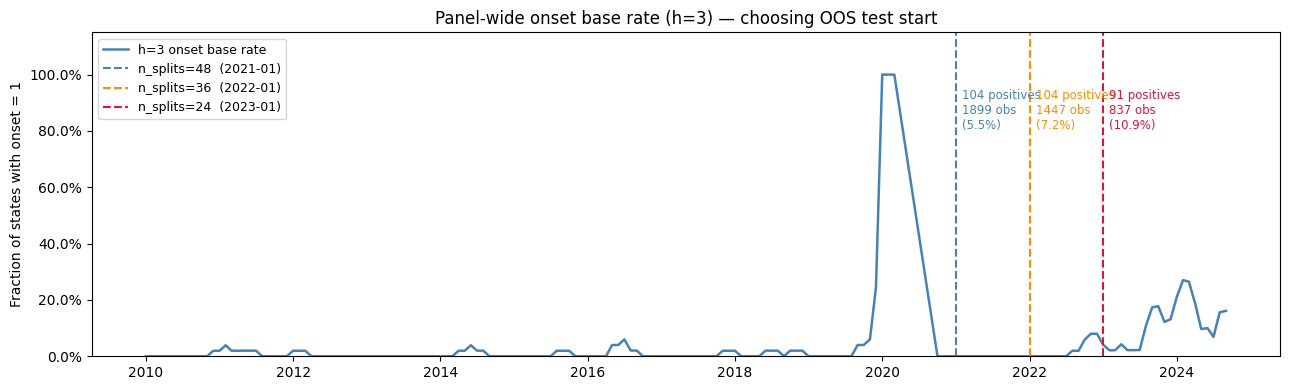

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

candidate_starts = {
    "n_splits=48  (2021-01)": pd.Timestamp("2021-01-01"),
    "n_splits=36  (2022-01)": pd.Timestamp("2022-01-01"),
    "n_splits=24  (2023-01)": pd.Timestamp("2023-01-01"),
}
colors = ["steelblue", "darkorange", "crimson"]

base_rate = ons_df.groupby("date")[ons_target_col].mean().dropna()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(base_rate.index, base_rate.values, lw=1.8, color="steelblue",
        label=f"h={horizon} onset base rate")
ax.set_ylabel("Fraction of states with onset = 1")
ax.set_title(f"Panel-wide onset base rate (h={horizon}) — choosing OOS test start")
ax.set_ylim(0, base_rate.max() * 1.15)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

for (label, ts), color in zip(candidate_starts.items(), colors):
    ax.axvline(ts, linestyle="--", color=color, lw=1.5, label=label)
    sub = ons_df[ons_df.index.get_level_values("date") >= ts]
    n_pos = int(sub[ons_target_col].sum())
    n_obs = int(sub[ons_target_col].notna().sum())
    ax.text(ts + pd.DateOffset(months=1), base_rate.max() * 0.95,
            f"{n_pos} positives\n{n_obs} obs\n({100*n_pos/n_obs:.1f}%)",
            color=color, fontsize=8.5, va="top")

ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Sanity check — onset NaN structure

Verify onset is NaN where: (a) state is currently in shock (`sahm_shock=1`), (b) last 3 rows per state.

In [6]:
ca = laus_raw.index.get_level_values("state_code") == "CA"
ca_view = ons_df.loc[ca]
print("=== California — last 24 rows ===")
print("Onset is NaN where sahm_shock=1 (in shock) OR last 3 rows (no forward window)")
ca_view.tail(24)

=== California — last 24 rows ===
Onset is NaN where sahm_shock=1 (in shock) OR last 3 rows (no forward window)


sahm_shock  anysahm_shock_th0  ons_anysahm_shock_th0_h3
state_code date                                                               
CA         2023-01-01           0                  0                       1.0
           2023-02-01           1                  1                       NaN
           2023-03-01           1                  1                       NaN
           2023-04-01           1                  1                       NaN
           2023-05-01           1                  1                       NaN
           2023-06-01           1                  1                       NaN
           2023-07-01           1                  1                       NaN
           2023-08-01           1                  1                       NaN
           2023-09-01           1                  1                       NaN
           2023-10-01           1                  1                       NaN
           2023-11-01           1                  1                       NaN
           2023-12-01           1                  1                       NaN
           2024-01-01           1                  1                       NaN
           2024-02-01           1                  1                       NaN
           2024-03-01           1                  1                       NaN
           2024-04-01           1                  1                       NaN
           2024-05-01           1                  1                       NaN
           2024-06-01           1                  1                       NaN
           2024-07-01           1                  1                       NaN
           2024-08-01           1                  1                       NaN
           2024-09-01           1                  1                       NaN
           2024-10-01           1                  1                       NaN
           2024-11-01           0                  0                       NaN
           2024-12-01           0                  0                       NaN

## Feature encoding

In [7]:
# One-hot encode state and month-of-year dummies before set_index
state_dummies = pd.get_dummies(panel_feat["state_code"], prefix="state", dtype=int)
month_dummies = pd.get_dummies(panel_feat["month_of_year"], prefix="moy",   dtype=int)
panel_enc = pd.concat([panel_feat, state_dummies, month_dummies], axis=1)

# Set MultiIndex — required by gen_test_labels and cross_val_fit_predict
panel_enc = panel_enc.set_index(["state_code", "date"]).sort_index()

STATE_COLS = state_dummies.columns.tolist()
MOY_COLS   = month_dummies.columns.tolist()

print(f"Encoded panel: {panel_enc.shape}")
print(f"State dummies: {len(STATE_COLS)}   Month dummies: {len(MOY_COLS)}")
print(f"Date range:    {panel_enc.index.get_level_values('date').min().strftime('%Y-%m')} "
      f"→ {panel_enc.index.get_level_values('date').max().strftime('%Y-%m')}")

Encoded panel: (8415, 111)
State dummies: 51   Month dummies: 12
Date range:    2011-04 → 2024-12


## Align targets with features

TargetEngineer ran on the full 9180-row LAUS panel. Feature engineering in notebook 04 dropped early rows
with NaN AR lags → 8415 rows. We inner-join to align. The `months_since_last_sahm_shock` column is
retained in the labels DataFrame — needed by the evaluation notebook for the "hard cases" since-filter.

In [8]:
since_col = "months_since_last_sahm_shock"

ons_df_aligned = ons_df.reindex(panel_enc.index)

ons_labels_df = ons_df_aligned.merge(
    panel_enc[[since_col]], left_index=True, right_index=True, how="left"
)

print(f"Aligned rows:            {len(ons_df_aligned)}")
print(f"Onset NaN target rows:   {ons_df_aligned[ons_target_col].isna().sum()}")

Aligned rows:            8415
Onset NaN target rows:   1096


## Feature set definitions

Four model specifications, each adding a richer feature group:
- **M0**: AR(1) persistence + state + month fixed effects
- **M2**: M0 + AR lags 2–12, changes, rolling std + since-variables + FRED macro
- **M3**: M2 + state-level leading indicators (UI claims, payrolls)
- **M4**: M3 + Google Trends text features (6 terms × 4 transformations) + PCA component

In [9]:
FEATURES_M0 = ["ur_lag1"] + STATE_COLS + MOY_COLS

AR_LAGS    = ["ur_lag2", "ur_lag3", "ur_lag6", "ur_lag12", "ur_chg1", "ur_chg3", "ur_std3"]
SINCE_VARS = ["months_since_last_sahm_shock", "cumulative_sahm_shocks_24m", "sahm_gap_lag1"]
FRED_LAGS  = ["unrate_nat_lag1", "icsa_mean_lag1", "vix_mean_lag1",
              "nasdaq_logret_lag1", "t10y2y_mean_lag1"]
FEATURES_M2 = FEATURES_M0 + AR_LAGS + SINCE_VARS + FRED_LAGS

STATE_LEADING = ["log_claims_lag1", "payrolls_yoy_lag1"]
FEATURES_M3 = FEATURES_M2 + STATE_LEADING

GT_TERMS       = ["file_for_unemployment", "jobs_hiring", "layoffs",
                   "resume", "unemployment", "unemployment_benefits"]
GT_FEATURES    = [f"gt_{t}_{s}" for t in GT_TERMS for s in ["z", "d1", "std3", "yoy"]]
PCA_INPUT_COLS = [f"gt_{t}_z" for t in GT_TERMS]   # 6 z-scored levels → 1 PCA component
FEATURES_M4    = FEATURES_M3 + GT_FEATURES

for name, feats in [("M0", FEATURES_M0), ("M2", FEATURES_M2),
                     ("M3", FEATURES_M3), ("M4", FEATURES_M4)]:
    print(f"{name:4s}: {len(feats):3d} features")

M0  :  64 features
M2  :  79 features
M3  :  81 features
M4  : 105 features


## PanelSplit + model factory

Expanding window with `n_splits=36`, `test_size=1`, `gap=horizon−1=2`.

`gap=2` is required for h=3: the training target at time T looks ahead to {T+1, T+2, T+3}, and the test target at T+3 looks ahead to {T+4, T+5, T+6}. With gap=2, training ends at T so the two windows share no periods — preventing any overlap between training labels and test labels.

In [10]:
n_splits  = 36
test_size = 1
gap       = horizon - 1   # = 2

ons_ps = PanelSplit(
    periods=panel_enc.index.get_level_values("date"),
    n_splits=n_splits, test_size=test_size, gap=gap
)

first_tr, first_te = ons_ps._u_periods_cv[0]
last_tr,  last_te  = ons_ps._u_periods_cv[-1]
print(f"n_splits={n_splits}, gap={gap}")
print(f"First fold: train_end={pd.Timestamp(sorted(first_tr)[-1]).strftime('%Y-%m')}  "
      f"test={pd.Timestamp(sorted(first_te)[0]).strftime('%Y-%m')}")
print(f"Last  fold: train_end={pd.Timestamp(sorted(last_tr)[-1]).strftime('%Y-%m')}   "
      f"test={pd.Timestamp(sorted(last_te)[0]).strftime('%Y-%m')}")

n_splits=36, gap=2
First fold: train_end=2021-10  test=2022-01
Last  fold: train_end=2024-09   test=2024-12


In [11]:
def make_rf():
    return RandomForestClassifier(
        max_depth=5, max_features=0.2, min_samples_leaf=15, class_weight="balanced", random_state=200
    )

def make_m4_pipeline():
    """Pipeline: PCA on GT z-scored cols (fit on train only) + passthrough rest + RF."""
    # Use integer positions so the transformer works on both DataFrames and arrays
    pca_idx  = [FEATURES_M4.index(c) for c in PCA_INPUT_COLS]
    pass_idx = [i for i in range(len(FEATURES_M4)) if i not in pca_idx]

    prep = ColumnTransformer([
        ("pca", make_pipeline(
            SimpleImputer(strategy="constant", fill_value=0),
            PCA(n_components=1)
        ), pca_idx),
        ("pass", "passthrough", pass_idx),
    ])
    return Pipeline([("prep", prep), ("rf", make_rf())])

MODELS = {
    "M0": (FEATURES_M0, make_rf()),
    "M2": (FEATURES_M2, make_rf()),
    "M3": (FEATURES_M3, make_rf()),
    "M4": (FEATURES_M4, make_m4_pipeline()),
}

## Rolling forecast — onset

`drop_na_in_y=True` is critical: onset is NaN whenever the state is currently in a shock. Those rows are excluded from training in every fold automatically.

In [12]:
MODELS = {
    "M0": (FEATURES_M0, make_rf()),
    "M2": (FEATURES_M2, make_rf()),
    "M3": (FEATURES_M3, make_rf()),
    "M4": (FEATURES_M4, make_m4_pipeline()),
}

ons_final_preds = ons_ps.gen_test_labels(ons_labels_df)

print("Running onset rolling forecast...")
for model_name, (feats, estimator) in MODELS.items():
    t0 = time.time()
    preds, _ = cross_val_fit_predict(
        estimator=estimator,
        X=panel_enc[feats],
        y=ons_df_aligned[ons_target_col],
        cv=ons_ps,
        method="predict_proba",
        drop_na_in_y=True,
    )
    ons_final_preds[f"ons_preds_{model_name}"] = preds[:, 1]
    print(f"  {model_name} done in {time.time()-t0:.1f}s")

print(f"\nOnset predictions shape: {ons_final_preds.shape}")
ons_final_preds.head()

Running onset rolling forecast...
  M0 done in 3.6s
  M2 done in 7.0s
  M3 done in 8.4s
  M4 done in 21.0s

Onset predictions shape: (1836, 8)


sahm_shock  anysahm_shock_th0  \
state_code date                                        
AK         2022-01-01           0                  0   
           2022-02-01           0                  0   
           2022-03-01           0                  0   
           2022-04-01           0                  0   
           2022-05-01           0                  0   

                       ons_anysahm_shock_th0_h3  months_since_last_sahm_shock  \
state_code date                                                                 
AK         2022-01-01                       0.0                          21.0   
           2022-02-01                       0.0                          22.0   
           2022-03-01                       0.0                          23.0   
           2022-04-01                       0.0                          24.0   
           2022-05-01                       0.0                          25.0   

                       ons_preds_M0  ons_preds_M2  ons_preds_M3  ons_preds_M4  
state_code date                                                                
AK         2022-01-01      0.581988      0.103189      0.056071      0.065258  
           2022-02-01      0.556069      0.061341      0.007751      0.017114  
           2022-03-01      0.506531      0.052388      0.066779      0.060720  
           2022-04-01      0.304987      0.252320      0.193018      0.113759  
           2022-05-01      0.345230      0.155680      0.195437      0.070084

## Save + pooled OOS metrics

In [13]:
ons_final_preds.to_parquet(P / "onset_predictions.parquet")
print("Saved onset_predictions.parquet")

sub = ons_final_preds.dropna(subset=[ons_target_col])
print(f"\n=== Onset OOS metrics ===")
print(f"{'Model':<6}  {'AUC-ROC':>9}  {'AUC-PR':>9}  {'Positives':>10}  {'N':>6}")
print("-" * 46)
for m in ["M0", "M2", "M3", "M4"]:
    col   = f"ons_preds_{m}"
    valid = sub.dropna(subset=[col])
    auc_roc = roc_auc_score(valid[ons_target_col], valid[col])
    auc_pr  = average_precision_score(valid[ons_target_col], valid[col])
    print(f"{m:<6}  {auc_roc:9.4f}  {auc_pr:9.4f}  {int(valid[ons_target_col].sum()):10d}  {len(valid):6d}")
print(f"No-skill AUC-PR baseline: {sub[ons_target_col].mean():.4f}")

Saved onset_predictions.parquet

=== Onset OOS metrics ===
Model     AUC-ROC     AUC-PR   Positives       N
----------------------------------------------
M0         0.5274     0.0733         104    1447
M2         0.8354     0.2930         104    1447
M3         0.8397     0.2923         104    1447
M4         0.8460     0.3239         104    1447
No-skill AUC-PR baseline: 0.0719


In [14]:
# ── Information set check ─────────────────────────────────────────────────────
# Verify: at prediction date T (end of month), do all feature values
# correspond to data that was actually published by then?

state     = "CA"
test_date = pd.Timestamp("2020-04-01")   # ← change to any date in the panel

T   = test_date
T_1 = T - pd.DateOffset(months=1)
T_2 = T - pd.DateOffset(months=2)

row = panel_enc.loc[(state, T)]   # the feature row the model sees at prediction time

fred_raw = pd.read_parquet(Path("../data/interim/fred_macro.parquet")
                            ).rename(columns={"month": "date"}).set_index("date")

print(f"{'='*62}")
print(f"Prediction date : end of {T.strftime('%Y-%m')}  (state: {state})")
print(f"Forecasting     : {(T + pd.DateOffset(months=1)).strftime('%Y-%m')}  (h=1)")
print(f"{'='*62}")

# ── Group B: UR lags ──────────────────────────────────────────────────────────
ur_T   = laus_raw.loc[(state, T),   "unemployment_rate"]
ur_T_1 = laus_raw.loc[(state, T_1), "unemployment_rate"]
ur_T_2 = laus_raw.loc[(state, T_2), "unemployment_rate"]

print(f"\nGroup B — UR lags  (BLS LAUS published ~4 weeks after ref month)")
print(f"  Raw UR  T   {T.strftime('%Y-%m')} = {ur_T:.2f}%   ← NOT yet published at end of {T.strftime('%b')}")
print(f"  Raw UR  T-1 {T_1.strftime('%Y-%m')} = {ur_T_1:.2f}%   ← published mid-{T.strftime('%b')} ✓")
print(f"  ur_lag1 in panel           = {row['ur_lag1']:.2f}%  match T-1: {'✓' if abs(row['ur_lag1'] - ur_T_1) < 0.01 else '✗ MISMATCH'}")
print(f"  ur_lag2 in panel           = {row['ur_lag2']:.2f}%  match T-2: {'✓' if abs(row['ur_lag2'] - ur_T_2) < 0.01 else '✗ MISMATCH'}")

# ── Group D: Macro lags ───────────────────────────────────────────────────────
nat_T_1 = fred_raw.loc[T_1, "unrate_nat"]
print(f"\nGroup D — Macro lags  (all shifted by 1)")
print(f"  Raw national UR T-1 {T_1.strftime('%Y-%m')} = {nat_T_1:.1f}%")
print(f"  unrate_nat_lag1 in panel   = {row['unrate_nat_lag1']:.1f}%  match T-1: {'✓' if abs(row['unrate_nat_lag1'] - nat_T_1) < 0.01 else '✗ MISMATCH'}")

# ── Group C: since-variables ──────────────────────────────────────────────────
sahm_T_1 = laus_raw.loc[(state, T_1), "sahm_gap"]
print(f"\nGroup C — Since-variables")
print(f"  Raw sahm_gap T-1 {T_1.strftime('%Y-%m')} = {sahm_T_1:.3f}")
print(f"  sahm_gap_lag1 in panel     = {row['sahm_gap_lag1']:.3f}  match T-1: {'✓' if abs(row['sahm_gap_lag1'] - sahm_T_1) < 0.001 else '✗ MISMATCH'}")

# ── Group A: Google Trends (no lag) ───────────────────────────────────────────
print(f"\nGroup A — Google Trends  (NO lag applied)")
for term in ["gt_unemployment_z", "gt_layoffs_z", "gt_file_for_unemployment_z"]:
    print(f"  {term} at T ({T.strftime('%Y-%m')}) = {row[term]:.3f}  ← uses {T.strftime('%Y-%m')} GT data")
print(f"  ⚠  Valid only if prediction is made AFTER {T.strftime('%Y-%m')} monthly data is final")
print(f"     (Google publishes monthly data by end of month — OK for end-of-month prediction)")
print(f"     Add shift(1) to GT features if you want start-of-month prediction semantics.")

print(f"\n{'='*62}")
print(f"Conclusion: all lagged features (B/C/D) use data ≤ T-1 ✓")
print(f"Google Trends uses T — acceptable if prediction = end of month.")
print(f"GT z-scores: expanding window (shift-1) — look-ahead bias corrected ")
print(f"{'='*62}")


Prediction date : end of 2020-04  (state: CA)
Forecasting     : 2020-05  (h=1)

Group B — UR lags  (BLS LAUS published ~4 weeks after ref month)
  Raw UR  T   2020-04 = 16.10%   ← NOT yet published at end of Apr
  Raw UR  T-1 2020-03 = 5.50%   ← published mid-Apr ✓
  ur_lag1 in panel           = 5.50%  match T-1: ✓
  ur_lag2 in panel           = 4.40%  match T-2: ✓

Group D — Macro lags  (all shifted by 1)
  Raw national UR T-1 2020-03 = 4.4%
  unrate_nat_lag1 in panel   = 4.4%  match T-1: ✓

Group C — Since-variables
  Raw sahm_gap T-1 2020-03 = 0.733
  sahm_gap_lag1 in panel     = 0.733  match T-1: ✓

Group A — Google Trends  (NO lag applied)
  gt_unemployment_z at T (2020-04) = 19.243  ← uses 2020-04 GT data
  gt_layoffs_z at T (2020-04) = 11.831  ← uses 2020-04 GT data
  gt_file_for_unemployment_z at T (2020-04) = 12.985  ← uses 2020-04 GT data
  ⚠  Valid only if prediction is made AFTER 2020-04 monthly data is final
     (Google publishes monthly data by end of month — OK for end-

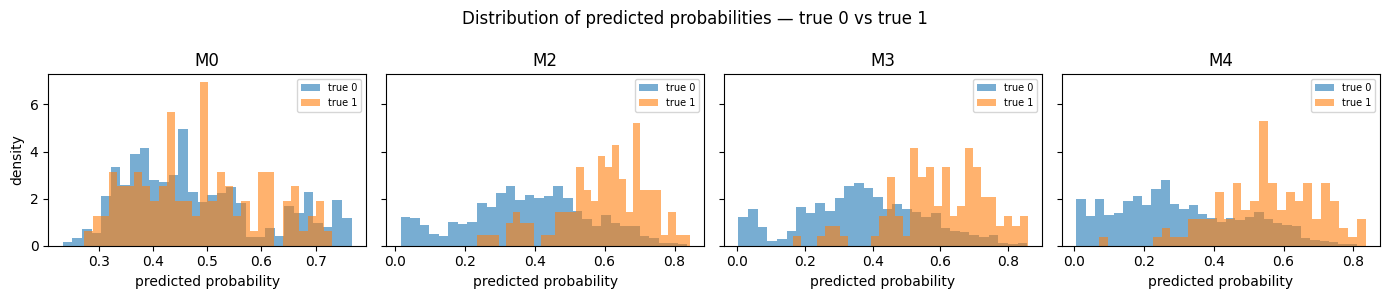

Model    mean(pred|y=0)   mean(pred|y=1)    separation
-------------------------------------------------------
M0                0.479            0.486         0.007
M2                0.380            0.596         0.216
M3                0.369            0.598         0.229
M4                0.303            0.554         0.250


In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
for ax, m in zip(axes, ["M0", "M2", "M3", "M4"]):
    col = f"ons_preds_{m}"
    sub = ons_final_preds.dropna(subset=[ons_target_col])
    ax.hist(sub.loc[sub[ons_target_col]==0, col], bins=30, alpha=0.6, label="true 0", density=True)
    ax.hist(sub.loc[sub[ons_target_col]==1, col], bins=30, alpha=0.6, label="true 1", density=True)
    ax.set_title(m)
    ax.set_xlabel("predicted probability")
    ax.legend(fontsize=7)
axes[0].set_ylabel("density")
plt.suptitle("Distribution of predicted probabilities — true 0 vs true 1")
plt.tight_layout()
plt.show()

# Also print summary stats per model
print(f"{'Model':<6}  {'mean(pred|y=0)':>15}  {'mean(pred|y=1)':>15}  {'separation':>12}")
print("-" * 55)
for m in ["M0", "M2", "M3", "M4"]:
    col = f"ons_preds_{m}"
    sub = ons_final_preds.dropna(subset=[ons_target_col, col])
    m0 = sub.loc[sub[ons_target_col]==0, col].mean()
    m1 = sub.loc[sub[ons_target_col]==1, col].mean()
    print(f"{m:<6}  {m0:>15.3f}  {m1:>15.3f}  {m1-m0:>12.3f}")


In [16]:
# Systematic information set check across all OOS test dates
test_dates = sorted(ons_final_preds.index.get_level_values("date").unique())
state = "CA"  # pick any state present throughout

fred_raw = pd.read_parquet(Path("../data/interim/fred_macro.parquet")
                           ).rename(columns={"month": "date"}).set_index("date")

results = []
for T in test_dates:
    T_1 = T - pd.DateOffset(months=1)
    try:
        row    = panel_enc.loc[(state, T)]
        ur_T_1 = laus_raw.loc[(state, T_1), "unemployment_rate"]
        nat_T_1 = fred_raw.loc[T_1, "unrate_nat"]
        sahm_T_1 = laus_raw.loc[(state, T_1), "sahm_gap"]

        results.append({
            "date": T.strftime("%Y-%m"),
            "ur_lag1_ok":      abs(row["ur_lag1"]        - ur_T_1)  < 0.01,
            "nat_ur_lag1_ok":  abs(row["unrate_nat_lag1"] - nat_T_1) < 0.01,
            "sahm_lag1_ok":    abs(row["sahm_gap_lag1"]  - sahm_T_1) < 0.001,
            "gt_uses_T":       True,  # GT always uses current month
        })
    except KeyError:
        results.append({"date": T.strftime("%Y-%m"),
                        "ur_lag1_ok": None, "nat_ur_lag1_ok": None,
                        "sahm_lag1_ok": None, "gt_uses_T": None})

df_check = pd.DataFrame(results).set_index("date")

# Summary
print("=== Information set check — all OOS months ===")
print(f"ur_lag1    correct: {df_check['ur_lag1_ok'].sum()}/{len(df_check)}")
print(f"nat_ur_lag1 correct: {df_check['nat_ur_lag1_ok'].sum()}/{len(df_check)}")
print(f"sahm_lag1  correct: {df_check['sahm_lag1_ok'].sum()}/{len(df_check)}")
print(f"GT features: always use month T (end-of-month assumption applies to all {len(df_check)} months)")

# Flag any failures
failures = df_check[~df_check[["ur_lag1_ok","nat_ur_lag1_ok","sahm_lag1_ok"]].all(axis=1)]
if len(failures):
    print(f"\n⚠ FAILURES in {len(failures)} months:")
    print(failures)
else:
    print("\n✓ No failures — lag structure correct across all OOS months")


=== Information set check — all OOS months ===
ur_lag1    correct: 36/36
nat_ur_lag1 correct: 36/36
sahm_lag1  correct: 36/36
GT features: always use month T (end-of-month assumption applies to all 36 months)

✓ No failures — lag structure correct across all OOS months


In [17]:
# Verify lag structure holds for ALL states in one month
T   = pd.Timestamp("2020-04-01")
T_1 = T - pd.DateOffset(months=1)

all_states = panel_enc.index.get_level_values("state_code").unique()
mismatches = []
for state in all_states:
    try:
        ur_feat = panel_enc.loc[(state, T), "ur_lag1"]
        ur_raw  = laus_raw.loc[(state, T_1), "unemployment_rate"]
        if abs(ur_feat - ur_raw) >= 0.01:
            mismatches.append(state)
    except KeyError:
        pass

if mismatches:
    print(f"⚠ Mismatches in: {mismatches}")
else:
    print(f"✓ ur_lag1 correct for all {len(all_states)} states at {T.strftime('%Y-%m')}")


✓ ur_lag1 correct for all 51 states at 2020-04
